# Master Price EDA

Starter notebook for the comparative workbook generated by `scripts.build_master_price_workbook`.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

WORKBOOK_PATH = Path(r"C:\Users\Dell-G3\Documents\Jupyter-projects\Others\agro-precios\data\analysis\master_price_workbook.xlsx")
COMPARE_SHEET = "compare_daily_wide"
COVERAGE_SHEET = "coverage"


In [2]:
compare_df = pd.read_excel(WORKBOOK_PATH, sheet_name=COMPARE_SHEET)
coverage_df = pd.read_excel(WORKBOOK_PATH, sheet_name=COVERAGE_SHEET)

compare_df["run_date"] = pd.to_datetime(compare_df["run_date"])
compare_df.head()


,run_date,canonical_product,query_year,sniim_daily_mean_mxn,sniim_daily_median_mxn,sniim_daily_min_mxn,sniim_daily_max_mxn,sniim_source_row_count,producto_nombre_sitio,walmart_comparison_mxn,...,chedraui_source_page,chedraui_product_raw,chedraui_product_inferred,chedraui_search_terms_used,cierre_annual_weighted_pmr_mxn_udm,cierre_unit_label,cierre_rows_used,cierre_total_produccion,cierre_crop_name,cierre_crop_label_raw
0,2026-04-09,aguacate,2026,44.806750,41.250,30.77,86.0,40.0,NaN,59.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-09,cebolla,2026,13.095455,12.500,6.00,25.0,22.0,NaN,23.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-04-09,chile_jalapeno,2026,41.070541,40.000,18.00,71.0,37.0,NaN,39.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-04-09,elote,2026,6.639500,6.625,3.33,9.0,20.0,NaN,14.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-04-09,limon,2026,31.714091,30.500,13.50,54.0,22.0,NaN,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


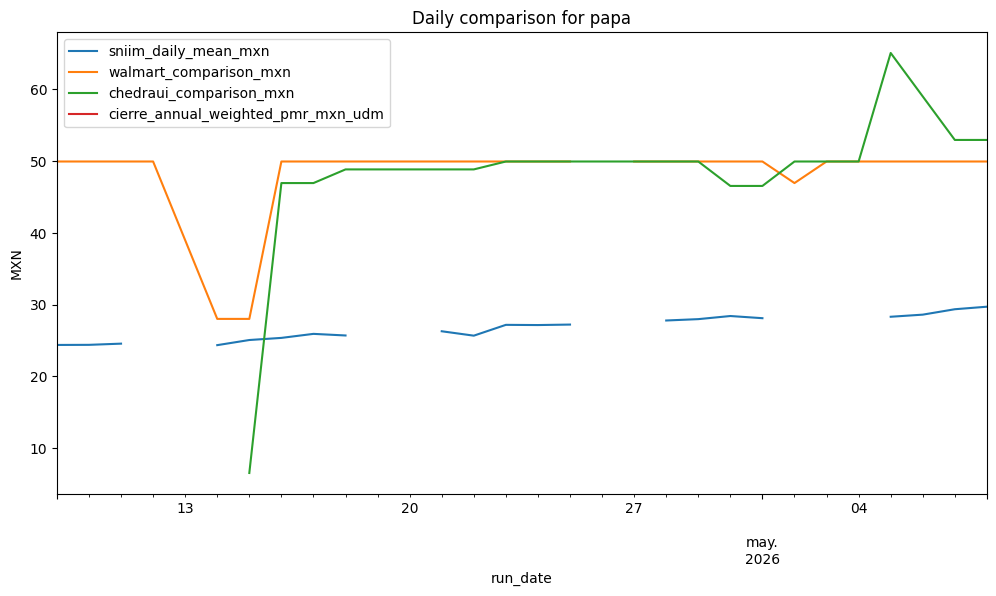

In [6]:
product = "papa"
product_df = compare_df[compare_df["canonical_product"] == product].sort_values("run_date")

ax = product_df.plot(
    x="run_date",
    y=[
        "sniim_daily_mean_mxn",
        "walmart_comparison_mxn",
        "chedraui_comparison_mxn",
        "cierre_annual_weighted_pmr_mxn_udm",
    ],
    figsize=(12, 6),
    title=f"Daily comparison for {product}",
)
ax.set_ylabel("MXN")
plt.show()


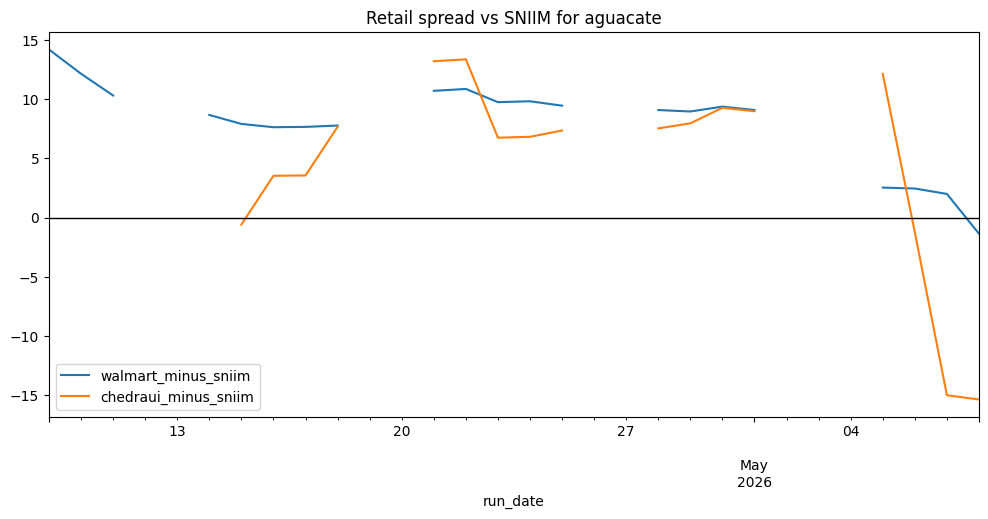

In [4]:
spread_df = product_df[["run_date", "canonical_product"]].copy()
spread_df["walmart_minus_sniim"] = product_df["walmart_comparison_mxn"] - product_df["sniim_daily_mean_mxn"]
spread_df["chedraui_minus_sniim"] = product_df["chedraui_comparison_mxn"] - product_df["sniim_daily_mean_mxn"]
spread_df.plot(x="run_date", y=["walmart_minus_sniim", "chedraui_minus_sniim"], figsize=(12, 5), title=f"Retail spread vs SNIIM for {product}")
plt.axhline(0, color="black", linewidth=1)
plt.show()


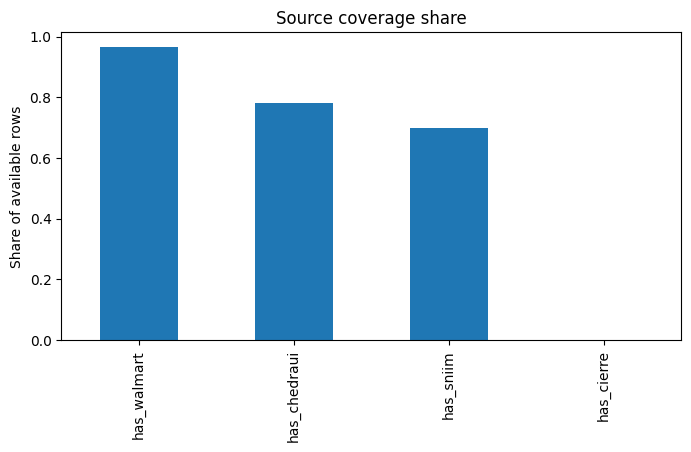

In [5]:
coverage_summary = coverage_df[["has_sniim", "has_walmart", "has_chedraui", "has_cierre"]].mean().sort_values(ascending=False)
coverage_summary.plot(kind="bar", figsize=(8, 4), title="Source coverage share")
plt.ylabel("Share of available rows")
plt.show()
